# CNN - VNINDEX

## Descriptions
1. Features: ["close"]
1. Target: "close"
1. Timeshift: 40
1. Forecast horizon: 1

## Deploy TensorBoard

In [184]:
# tensorboard --logdir=src/model/lightning_logs/

## Import libraries

In [185]:
import os
import sys
import pandas as pd
import lightning as L
import torch.nn as nn
import torch
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tsfresh.utilities.dataframe_functions import (
    roll_time_series,
)
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import ComprehensiveFCParameters
import matplotlib.pylab as plt
from sklearn.preprocessing import MinMaxScaler
from lightning.pytorch.callbacks import EarlyStopping
from dataclasses import asdict
import ipynbname

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from utils.constants import FEATURE_SELECTION_LOG_FILE_BASE
from dtos.config_dtos.config_dto import ConfigDto
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)
from utils.enums import (
    LossFunctionType,
    ModelAchitectureType,
    OptimizerType,
    ScalerType,
)

## Parameters

In [186]:
NOTEBOOK_NAME = ipynbname.name()
RANDOM_SEED = 18
MAX_TIMESHIFT = 60
MIN_TIMESHIFT = 5
FORECAST_HORIZON = 1
COLUMN_ID = "stock"
TARGET_COLUMN = "close"
DATE_COLUMN = "date"
FEATURE_COLUMNS = ["close"]

# Inclusive
TRAIN_RANGE = ("2000-01-01", "2021-12-31")
VALIDATION_RANGE = ("2022-01-01", "2023-12-31")
TEST_RANGE = ("2024-01-01", "2026-02-26")

OUTPUT_SIZE = 1

## Hyper Parameters

In [187]:
MAX_EPOCHS = 3000
LEARNING_RATE = 1.0e-06
PATIENCE = 100
BATCH_SIZE = 128

In [188]:
MODEL_PARAMS = {}

## Start

### Get data

In [189]:
my_logger = Logger(file_name=f"{FEATURE_SELECTION_LOG_FILE_BASE}/vn_index/test")

In [190]:
my_connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

In [191]:
my_postgresql_driver = PostgreSQLDriver(logger=my_logger)
my_postgresql_driver.connect(my_connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [192]:
vn_index_df = my_postgresql_driver.select(
    schema_name="stock_market", table_name="vn_index"
)

In [193]:
dtype_map = {
    "date": str,
    "open": float,
    "high": float,
    "low": float,
    "close": float,
    "matching_volume": float,
}

vn_index_df = (
    vn_index_df.astype(dtype_map)
    .dropna(subset=["close"])
    .sort_values(by=["date"])
    .reset_index(drop=True)
)

In [194]:
vn_index_df

,date,open,high,low,close,adjust,change,percent_change,matching_volume,matching_value,negotiate_volume,negotiate_value,number_of_buy_orders,buy_volume,average_volume_per_buy_order,number_of_sell_orders,sell_volume,average_volume_per_sell_order,net_volume
0,2008-03-07,640.140,640.140,640.140,640.140,640.14,28.97,4.74,8.169220e+06,515253831000.0,350040.0,29103040000.0,26816.0,5.268141e+07,1965.0,3448.0,9.057040e+06,2627.0,4.362437e+07
1,2008-03-08,646.190,646.190,646.190,646.190,646.1899999999999,25.363333333333333,4.1066666666666665,1.314382e+07,829832099333.3333,769057.0,45944657000.0,27442.0,5.068024e+07,1852.3333333333333,7486.0,1.712815e+07,2464.0,3.355209e+07
2,2008-03-09,652.240,652.240,652.240,652.240,652.24,21.756666666666664,3.4733333333333336,1.811842e+07,1144410367666.6665,1188073.0,62786274000.0,28068.0,4.867907e+07,1739.6666666666667,11523.0,2.519927e+07,2301.0,2.347980e+07
3,2008-03-10,658.290,658.290,658.290,658.290,658.29,18.15,2.84,2.309302e+07,1458988636000.0,1607090.0,79627891000.0,28694.0,4.667790e+07,1627.0,15561.0,3.327038e+07,2138.0,1.340752e+07
4,2008-03-11,638.710,638.710,638.710,638.710,638.71,-19.58,-2.97,1.384280e+07,837466500000.0,226000.0,12099600000.0,14464.0,1.933131e+07,1337.0,17910.0,2.811427e+07,1570.0,-8.782960e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6561,2026-02-22,1832.317,1859.236,1829.801,1856.535,1856.535,33.44499999999999,1.837,7.158068e+08,22272405365000.0,23581058.0,792440247700.0,476711.0,1.233848e+09,2591.3,393692.0,1.198445e+09,3047.9,3.540296e+07
6562,2026-02-23,1833.900,1863.130,1833.900,1860.140,1860.14,36.05,1.98,7.313611e+08,22646206050000.0,23192200.0,777430868000.0,486603.0,1.253004e+09,2575.0,401281.0,1.213944e+09,3025.0,3.906029e+07
6563,2026-02-24,1862.180,1867.690,1849.600,1867.620,1867.62,7.48,0.4,9.667547e+08,31205940310000.0,22413147.0,779573446300.0,598087.0,1.575227e+09,2634.0,507471.0,1.648273e+09,3248.0,-7.304628e+07
6564,2026-02-25,1869.490,1876.010,1855.890,1860.910,1860.91,-6.71,-0.36,1.083635e+09,35678521520000.0,62225450.0,1856894317550.0,694266.0,1.862364e+09,2682.0,597096.0,1.892734e+09,3170.0,-3.036983e+07


In [195]:
vn_index_df_close = vn_index_df[[DATE_COLUMN] + FEATURE_COLUMNS]
vn_index_df_close

,date,close
0,2008-03-07,640.140
1,2008-03-08,646.190
2,2008-03-09,652.240
3,2008-03-10,658.290
4,2008-03-11,638.710
...,...,...
6561,2026-02-22,1856.535
6562,2026-02-23,1860.140
6563,2026-02-24,1867.620
6564,2026-02-25,1860.910


In [196]:
vn_index_df_close.loc[:, "stock"] = "vn_index"
vn_index_df_close

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_15984\2662759176.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vn_index_df_close.loc[:, "stock"] = "vn_index"


,date,close,stock
0,2008-03-07,640.140,vn_index
1,2008-03-08,646.190,vn_index
2,2008-03-09,652.240,vn_index
3,2008-03-10,658.290,vn_index
4,2008-03-11,638.710,vn_index
...,...,...,...
6561,2026-02-22,1856.535,vn_index
6562,2026-02-23,1860.140,vn_index
6563,2026-02-24,1867.620,vn_index
6564,2026-02-25,1860.910,vn_index


In [197]:
input_df = vn_index_df_close

### Roll time series

In [198]:
input_df_rolled = roll_time_series(
    input_df,
    column_id=COLUMN_ID,
    column_sort=DATE_COLUMN,
    max_timeshift=MAX_TIMESHIFT,
    min_timeshift=MIN_TIMESHIFT,
)
input_df_rolled

Rolling: 100%|██████████| 50/50 [00:11<00:00,  4.27it/s]


,date,close,stock,id
0,2008-03-07,640.140,vn_index,"(vn_index, 2008-03-12)"
1,2008-03-08,646.190,vn_index,"(vn_index, 2008-03-12)"
2,2008-03-09,652.240,vn_index,"(vn_index, 2008-03-12)"
3,2008-03-10,658.290,vn_index,"(vn_index, 2008-03-12)"
4,2008-03-11,638.710,vn_index,"(vn_index, 2008-03-12)"
...,...,...,...,...
398676,2026-02-22,1856.535,vn_index,"(vn_index, 2026-02-26)"
398677,2026-02-23,1860.140,vn_index,"(vn_index, 2026-02-26)"
398678,2026-02-24,1867.620,vn_index,"(vn_index, 2026-02-26)"
398679,2026-02-25,1860.910,vn_index,"(vn_index, 2026-02-26)"


### Extract features

In [199]:
X = extract_features(
    input_df_rolled.drop(COLUMN_ID, axis=1),
    column_id="id",
    column_sort=DATE_COLUMN,
    impute_function=impute,
    default_fc_parameters=ComprehensiveFCParameters(),
)

Feature Extraction: 100%|██████████| 50/50 [01:59<00:00,  2.40s/it]


In [200]:
X

close__variance_larger_than_standard_deviation  \
vn_index 2008-03-12                                             1.0   
         2008-03-13                                             1.0   
         2008-03-14                                             1.0   
         2008-03-15                                             1.0   
         2008-03-16                                             1.0   
...                                                             ...   
         2026-02-22                                             1.0   
         2026-02-23                                             1.0   
         2026-02-24                                             1.0   
         2026-02-25                                             1.0   
         2026-02-26                                             1.0   

                     close__has_duplicate_max  close__has_duplicate_min  \
vn_index 2008-03-12                       0.0                       0.0   
         2008-03-13                       0.0                       0.0   
         2008-03-14                       0.0                       0.0   
         2008-03-15                       0.0                       0.0   
         2008-03-16                       0.0                       0.0   
...                                       ...                       ...   
         2026-02-22                       0.0                       0.0   
         2026-02-23                       0.0                       0.0   
         2026-02-24                       0.0                       0.0   
         2026-02-25                       0.0                       0.0   
         2026-02-26                       0.0                       0.0   

                     close__has_duplicate  close__sum_values  \
vn_index 2008-03-12                   0.0        3879.470000   
         2008-03-13                   0.0        4527.070000   
         2008-03-14                   0.0        5170.870000   
         2008-03-15                   0.0        5805.306667   
         2008-03-16                   0.0        6430.380000   
...                                   ...                ...   
         2026-02-22                   0.0      111204.545000   
         2026-02-23                   0.0      111281.865000   
         2026-02-24                   0.0      111406.635000   
         2026-02-25                   0.0      111537.745000   
         2026-02-26                   0.0      111679.238333   

                     close__abs_energy  close__mean_abs_change  \
vn_index 2008-03-12       2.508661e+06                8.584000   
         2008-03-13       2.928047e+06                7.770000   
         2008-03-14       3.342525e+06                7.202857   
         2008-03-15       3.745035e+06                7.472917   
         2008-03-16       4.135752e+06                7.682963   
...                                ...                     ...   
         2026-02-22       2.028662e+08               10.320583   
         2026-02-23       2.031479e+08                9.714500   
         2026-02-24       2.035984e+08                9.621667   
         2026-02-25       2.040692e+08                9.594389   
         2026-02-26       2.045811e+08                9.767444   

                     close__mean_change  \
vn_index 2008-03-12            0.752000   
         2008-03-13            1.243333   
         2008-03-14            0.522857   
         2008-03-15           -0.712917   
         2008-03-16           -1.674074   
...                                 ...   
         2026-02-22            1.228583   
         2026-02-23            1.954833   
         2026-02-24            2.297000   
         2026-02-25            2.046056   
         2026-02-26            2.219111   

                     close__mean_second_derivative_central  close__median  \
vn_index 2008-03-12                              -0.107500        645.045   
         2008-03-13               

In [201]:
X = X.set_index(X.index.map(lambda x: x[1]), drop=True)
X.index.name = "last_date"
X

,close__variance_larger_than_standard_deviation,close__has_duplicate_max,close__has_duplicate_min,close__has_duplicate,close__sum_values,close__abs_energy,close__mean_abs_change,close__mean_change,close__mean_second_derivative_central,close__median,...,close__fourier_entropy__bins_5,close__fourier_entropy__bins_10,close__fourier_entropy__bins_100,close__permutation_entropy__dimension_3__tau_1,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_5__tau_1,close__permutation_entropy__dimension_6__tau_1,close__permutation_entropy__dimension_7__tau_1,close__query_similarity_count__query_None__threshold_0.0,close__mean_n_absolute_max__number_of_maxima_7
last_date,,,,,,,,,,,,,,,,,,,,,
2008-03-12,1.0,0.0,0.0,0.0,3879.470000,2.508661e+06,8.584000,0.752000,-0.107500,645.045,...,0.693147,1.386294,1.386294,1.039721,1.098612,0.693147,-0.000000,3.658850,0.0,716.614286
2008-03-13,1.0,0.0,0.0,0.0,4527.070000,2.928047e+06,7.770000,1.243333,-0.235000,646.190,...,1.386294,1.386294,1.386294,0.950271,1.386294,1.098612,0.693147,-0.000000,0.0,716.614286
2008-03-14,1.0,0.0,0.0,0.0,5170.870000,3.342525e+06,7.202857,0.522857,-0.820833,645.045,...,1.332179,1.609438,1.609438,1.011404,1.609438,1.386294,1.098612,0.693147,0.0,647.451429
2008-03-15,1.0,0.0,0.0,0.0,5805.306667,3.745035e+06,7.472917,-0.712917,-1.100952,643.900,...,1.609438,1.609438,1.609438,1.277034,1.791759,1.609438,1.386294,1.098612,0.0,647.451429
2008-03-16,1.0,0.0,0.0,0.0,6430.380000,4.135752e+06,7.682963,-1.674074,-0.963333,643.850,...,1.329661,1.560710,1.791759,1.320888,1.945910,1.791759,1.609438,1.386294,0.0,647.451429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-22,1.0,0.0,0.0,0.0,111204.545000,2.028662e+08,10.320583,1.228583,0.369280,1827.695,...,0.283936,0.424254,0.838120,1.254838,1.802253,2.337996,2.784597,3.089698,0.0,1892.700000
2026-02-23,1.0,0.0,0.0,0.0,111281.865000,2.031479e+08,9.714500,1.954833,0.141144,1829.040,...,0.283936,0.424254,0.838120,1.245421,1.767955,2.266629,2.715631,3.022899,0.0,1892.700000
2026-02-24,1.0,0.0,0.0,0.0,111406.635000,2.035984e+08,9.621667,2.297000,-0.007345,1830.500,...,0.283936,0.283936,0.928839,1.208122,1.694212,2.194463,2.645673,2.954887,0.0,1892.700000


### Create forecast target

In [202]:
y = (
    vn_index_df_close.set_index(DATE_COLUMN)
    .sort_index()[TARGET_COLUMN]
    .shift(-FORECAST_HORIZON)
    .dropna()
)
y = pd.DataFrame(y)
y

,close
date,
2008-03-07,646.190
2008-03-08,652.240
2008-03-09,658.290
2008-03-10,638.710
2008-03-11,643.900
...,...
2026-02-21,1856.535
2026-02-22,1860.140
2026-02-23,1867.620


In [203]:
y = y[y.index.isin(X.index)]
X = X[X.index.isin(y.index)]

In [204]:
X

,close__variance_larger_than_standard_deviation,close__has_duplicate_max,close__has_duplicate_min,close__has_duplicate,close__sum_values,close__abs_energy,close__mean_abs_change,close__mean_change,close__mean_second_derivative_central,close__median,...,close__fourier_entropy__bins_5,close__fourier_entropy__bins_10,close__fourier_entropy__bins_100,close__permutation_entropy__dimension_3__tau_1,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_5__tau_1,close__permutation_entropy__dimension_6__tau_1,close__permutation_entropy__dimension_7__tau_1,close__query_similarity_count__query_None__threshold_0.0,close__mean_n_absolute_max__number_of_maxima_7
last_date,,,,,,,,,,,,,,,,,,,,,
2008-03-12,1.0,0.0,0.0,0.0,3879.470000,2.508661e+06,8.584000,0.752000,-0.107500,645.045,...,0.693147,1.386294,1.386294,1.039721,1.098612,0.693147,-0.000000,3.658850,0.0,716.614286
2008-03-13,1.0,0.0,0.0,0.0,4527.070000,2.928047e+06,7.770000,1.243333,-0.235000,646.190,...,1.386294,1.386294,1.386294,0.950271,1.386294,1.098612,0.693147,-0.000000,0.0,716.614286
2008-03-14,1.0,0.0,0.0,0.0,5170.870000,3.342525e+06,7.202857,0.522857,-0.820833,645.045,...,1.332179,1.609438,1.609438,1.011404,1.609438,1.386294,1.098612,0.693147,0.0,647.451429
2008-03-15,1.0,0.0,0.0,0.0,5805.306667,3.745035e+06,7.472917,-0.712917,-1.100952,643.900,...,1.609438,1.609438,1.609438,1.277034,1.791759,1.609438,1.386294,1.098612,0.0,647.451429
2008-03-16,1.0,0.0,0.0,0.0,6430.380000,4.135752e+06,7.682963,-1.674074,-0.963333,643.850,...,1.329661,1.560710,1.791759,1.320888,1.945910,1.791759,1.609438,1.386294,0.0,647.451429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-21,1.0,0.0,0.0,0.0,111120.160000,2.025600e+08,10.438333,1.346333,-0.059873,1824.090,...,0.424254,0.424254,0.838120,1.305652,1.850741,2.408528,2.852511,3.155197,0.0,1892.700000
2026-02-22,1.0,0.0,0.0,0.0,111204.545000,2.028662e+08,10.320583,1.228583,0.369280,1827.695,...,0.283936,0.424254,0.838120,1.254838,1.802253,2.337996,2.784597,3.089698,0.0,1892.700000
2026-02-23,1.0,0.0,0.0,0.0,111281.865000,2.031479e+08,9.714500,1.954833,0.141144,1829.040,...,0.283936,0.424254,0.838120,1.245421,1.767955,2.266629,2.715631,3.022899,0.0,1892.700000


In [205]:
y

,close
date,
2008-03-12,647.600000
2008-03-13,643.800000
2008-03-14,634.436667
2008-03-15,625.073333
2008-03-16,615.710000
...,...
2026-02-21,1856.535000
2026-02-22,1860.140000
2026-02-23,1867.620000


### Create train set

In [206]:
TRAIN_RANGE[0], TRAIN_RANGE[1]

('2000-01-01', '2021-12-31')

In [207]:
X_train = X.loc[TRAIN_RANGE[0] : TRAIN_RANGE[1]]
X_train

,close__variance_larger_than_standard_deviation,close__has_duplicate_max,close__has_duplicate_min,close__has_duplicate,close__sum_values,close__abs_energy,close__mean_abs_change,close__mean_change,close__mean_second_derivative_central,close__median,...,close__fourier_entropy__bins_5,close__fourier_entropy__bins_10,close__fourier_entropy__bins_100,close__permutation_entropy__dimension_3__tau_1,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_5__tau_1,close__permutation_entropy__dimension_6__tau_1,close__permutation_entropy__dimension_7__tau_1,close__query_similarity_count__query_None__threshold_0.0,close__mean_n_absolute_max__number_of_maxima_7
last_date,,,,,,,,,,,,,,,,,,,,,
2008-03-12,1.0,0.0,0.0,0.0,3879.470000,2.508661e+06,8.584000,0.752000,-0.107500,645.045,...,0.693147,1.386294,1.386294,1.039721,1.098612,0.693147,-0.000000,3.658850,0.0,716.614286
2008-03-13,1.0,0.0,0.0,0.0,4527.070000,2.928047e+06,7.770000,1.243333,-0.235000,646.190,...,1.386294,1.386294,1.386294,0.950271,1.386294,1.098612,0.693147,-0.000000,0.0,716.614286
2008-03-14,1.0,0.0,0.0,0.0,5170.870000,3.342525e+06,7.202857,0.522857,-0.820833,645.045,...,1.332179,1.609438,1.609438,1.011404,1.609438,1.386294,1.098612,0.693147,0.0,647.451429
2008-03-15,1.0,0.0,0.0,0.0,5805.306667,3.745035e+06,7.472917,-0.712917,-1.100952,643.900,...,1.609438,1.609438,1.609438,1.277034,1.791759,1.609438,1.386294,1.098612,0.0,647.451429
2008-03-16,1.0,0.0,0.0,0.0,6430.380000,4.135752e+06,7.682963,-1.674074,-0.963333,643.850,...,1.329661,1.560710,1.791759,1.320888,1.945910,1.791759,1.609438,1.386294,0.0,647.451429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,1.0,0.0,0.0,0.0,89384.260000,1.309958e+08,6.884167,0.847833,-0.019576,1467.980,...,0.518700,0.867241,1.807218,1.544667,2.526621,3.213940,3.718945,3.881306,0.0,1490.664286
2021-12-28,1.0,0.0,0.0,0.0,89440.640000,1.311611e+08,6.871667,0.835333,0.061667,1468.180,...,0.518700,0.867241,1.807218,1.539194,2.515630,3.207979,3.694190,3.856101,0.0,1491.978571
2021-12-29,1.0,0.0,0.0,0.0,89482.190000,1.312828e+08,6.985056,0.721944,-0.057655,1469.830,...,0.518700,0.867241,1.848411,1.583838,2.552512,3.223120,3.669434,3.830896,0.0,1491.978571


In [208]:
y_train = y.loc[TRAIN_RANGE[0] : TRAIN_RANGE[1]]
y_train

,close
date,
2008-03-12,647.600000
2008-03-13,643.800000
2008-03-14,634.436667
2008-03-15,625.073333
2008-03-16,615.710000
...,...
2021-12-27,1494.390000
2021-12-28,1485.820000
2021-12-29,1485.970000


### Select features

In [209]:
X_train_selected = select_features(X_train, y_train[TARGET_COLUMN])
X_train_selected

,close__sum_values,"close__cwt_coefficients__coeff_5__w_20__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_5__w_10__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_5__w_5__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_5__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_4__w_20__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_4__w_10__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_4__w_5__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_4__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_3__w_20__widths_(2, 5, 10, 20)",...,close__count_below_mean,close__lempel_ziv_complexity__bins_2,close__fourier_entropy__bins_3,close__large_standard_deviation__r_0.35000000000000003,close__ratio_beyond_r_sigma__r_0.5,close__large_standard_deviation__r_0.30000000000000004,close__approximate_entropy__m_2__r_0.9,"close__agg_linear_trend__attr_""rvalue""__chunk_len_50__f_agg_""var""","close__linear_trend__attr_""pvalue""","close__fft_coefficient__attr_""angle""__coeff_28"
last_date,,,,,,,,,,,,,,,,,,,,,
2008-03-12,3879.470000,735.029620,962.032643,1006.561051,434.218410,743.451621,999.548403,1191.744136,699.986290,736.753424,...,4.0,0.666667,0.693147,0.0,0.666667,1.0,0.146987,-1.0,0.974177,3.485959
2008-03-13,4527.070000,861.469999,1129.502093,1223.538864,565.443649,858.451410,1163.299452,1359.997890,604.903479,858.591202,...,4.0,0.571429,1.039721,0.0,0.571429,1.0,0.253197,-1.0,0.918343,3.485959
2008-03-14,5170.870000,975.794991,1292.292280,1390.805336,470.918767,979.574265,1305.561673,1458.760861,434.051080,975.992231,...,5.0,0.500000,1.054920,0.0,0.500000,1.0,0.173549,-1.0,0.898556,3.485959
2008-03-15,5805.306667,1095.156253,1432.485460,1488.131913,302.551221,1095.267832,1432.970774,1489.960256,308.941001,1087.170468,...,5.0,0.555556,1.054920,0.0,0.555556,0.0,0.212904,-1.0,0.370408,3.485959
2008-03-16,6430.380000,1209.142356,1558.014194,1518.870851,179.287578,1204.805245,1537.111841,1462.898099,250.334480,1191.480143,...,4.0,0.500000,0.867563,0.0,0.500000,0.0,0.267115,-1.0,0.086674,3.485959
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,89384.260000,1653.033395,1722.202388,1675.311920,186.961512,1350.923165,1427.938885,1601.314135,471.510088,1041.292388,...,27.0,0.278689,0.473981,0.0,0.688525,0.0,0.377503,-1.0,0.000766,-114.642418
2021-12-28,89440.640000,1657.707779,1728.049289,1679.908742,186.715883,1355.702209,1433.416228,1604.595576,470.535199,1045.971979,...,26.0,0.278689,0.473981,0.0,0.721311,0.0,0.371337,-1.0,0.000746,118.321921
2021-12-29,89482.190000,1661.474562,1732.994323,1685.883622,188.168429,1359.436337,1438.005989,1608.884553,471.524034,1049.770603,...,26.0,0.262295,0.473981,0.0,0.688525,0.0,0.362195,-1.0,0.000834,-122.152376


### Create validation set

In [210]:
VALIDATION_RANGE[0], VALIDATION_RANGE[1]

('2022-01-01', '2023-12-31')

In [211]:
X_validation_selected = X.loc[VALIDATION_RANGE[0] : VALIDATION_RANGE[1]][
    X_train_selected.columns
]
X_validation_selected

,close__sum_values,"close__cwt_coefficients__coeff_5__w_20__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_5__w_10__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_5__w_5__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_5__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_4__w_20__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_4__w_10__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_4__w_5__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_4__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_3__w_20__widths_(2, 5, 10, 20)",...,close__count_below_mean,close__lempel_ziv_complexity__bins_2,close__fourier_entropy__bins_3,close__large_standard_deviation__r_0.35000000000000003,close__ratio_beyond_r_sigma__r_0.5,close__large_standard_deviation__r_0.30000000000000004,close__approximate_entropy__m_2__r_0.9,"close__agg_linear_trend__attr_""rvalue""__chunk_len_50__f_agg_""var""","close__linear_trend__attr_""pvalue""","close__fft_coefficient__attr_""angle""__coeff_28"
last_date,,,,,,,,,,,,,,,,,,,,,
2022-01-01,89649.335000,1673.440248,1751.030175,1707.785338,203.129965,1371.603676,1455.716687,1629.799968,482.066160,1062.080555,...,27.0,0.262295,0.473981,0.0,0.573770,0.0,0.359529,-1.0,8.069901e-04,81.415571
2022-01-02,89708.805000,1674.405536,1754.809123,1714.795672,204.225193,1373.062024,1459.342113,1636.358393,489.553174,1063.530053,...,28.0,0.278689,0.473981,0.0,0.524590,0.0,0.347325,-1.0,3.859024e-04,-169.071420
2022-01-03,89783.260000,1676.669719,1759.886986,1721.068988,198.916033,1375.355031,1464.759765,1643.770008,489.039260,1066.366459,...,28.0,0.262295,0.473981,0.0,0.524590,0.0,0.320222,-1.0,2.269654e-04,94.040003
2022-01-04,89860.500000,1677.640538,1764.104418,1725.894682,193.949154,1376.722187,1469.026299,1649.844651,484.526783,1067.742248,...,28.0,0.295082,0.550354,0.0,0.524590,0.0,0.303831,-1.0,1.094023e-04,175.807432
2022-01-05,89926.490000,1676.938878,1766.979124,1729.176634,194.158345,1376.275498,1471.603014,1654.268572,481.171017,1067.643237,...,28.0,0.278689,0.550354,0.0,0.557377,0.0,0.287991,-1.0,4.239704e-05,-41.292525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,67089.970000,1180.300173,1226.081706,1183.610287,114.588761,953.145637,1002.088254,1121.726741,305.668640,721.305621,...,22.0,0.213115,0.473981,0.0,0.524590,0.0,0.197984,-1.0,1.244508e-07,139.592833
2023-12-28,67164.353333,1189.007260,1239.816645,1198.563628,139.824348,961.480057,1014.303950,1131.751340,322.543982,728.752814,...,24.0,0.213115,0.473981,0.0,0.540984,0.0,0.204619,-1.0,2.125322e-07,-167.531919
2023-12-29,67245.810000,1198.629649,1255.954937,1216.628286,155.777548,971.271165,1029.258550,1147.003346,346.581915,738.206829,...,29.0,0.213115,0.379535,0.0,0.557377,0.0,0.204801,-1.0,4.033219e-07,145.015844


In [212]:
y_validation = y.loc[VALIDATION_RANGE[0] : VALIDATION_RANGE[1]]
y_validation

,close
date,
2022-01-01,1511.9300
2022-01-02,1518.7550
2022-01-03,1525.5800
2022-01-04,1522.5000
2022-01-05,1528.5700
...,...
2023-12-27,1128.9300
2023-12-28,1129.9300
2023-12-29,1130.3775


### Create test set

In [213]:
TEST_RANGE[0], TEST_RANGE[1]

('2024-01-01', '2026-02-26')

In [214]:
X_test_selected = X.loc[TEST_RANGE[0] : TEST_RANGE[1]][X_train_selected.columns]
X_test_selected

,close__sum_values,"close__cwt_coefficients__coeff_5__w_20__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_5__w_10__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_5__w_5__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_5__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_4__w_20__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_4__w_10__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_4__w_5__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_4__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_3__w_20__widths_(2, 5, 10, 20)",...,close__count_below_mean,close__lempel_ziv_complexity__bins_2,close__fourier_entropy__bins_3,close__large_standard_deviation__r_0.35000000000000003,close__ratio_beyond_r_sigma__r_0.5,close__large_standard_deviation__r_0.30000000000000004,close__approximate_entropy__m_2__r_0.9,"close__agg_linear_trend__attr_""rvalue""__chunk_len_50__f_agg_""var""","close__linear_trend__attr_""pvalue""","close__fft_coefficient__attr_""angle""__coeff_28"
last_date,,,,,,,,,,,,,,,,,,,,,
2024-01-01,67528.035000,1233.078798,1308.241713,1264.472941,145.800888,1006.117222,1083.652005,1200.477626,351.946293,773.879766,...,31.0,0.245902,0.239217,0.0,0.590164,0.0,0.290939,-1.0,0.000001,177.758948
2024-01-02,67601.535000,1240.498302,1320.081852,1274.613574,155.891164,1013.523293,1095.726266,1212.433352,354.480485,780.969068,...,31.0,0.278689,0.239217,0.0,0.639344,0.0,0.341629,-1.0,0.000002,172.491626
2024-01-03,67668.925000,1244.090053,1327.811003,1283.438361,166.121480,1017.265832,1103.839129,1221.661268,368.230769,784.596653,...,31.0,0.295082,0.239217,0.0,0.672131,0.0,0.332451,-1.0,0.000002,167.849943
2024-01-04,67738.571667,1247.095998,1333.220471,1291.489305,162.967520,1019.920816,1110.706076,1230.274924,379.307725,787.380644,...,33.0,0.262295,0.239217,0.0,0.754098,0.0,0.312211,-1.0,0.000002,-167.641395
2024-01-05,67807.885000,1248.258859,1337.620985,1298.738871,148.296256,1022.050831,1115.253343,1238.114737,377.000404,789.136714,...,32.0,0.278689,0.239217,0.0,0.786885,0.0,0.259473,-1.0,0.000001,159.184920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-21,111120.160000,2003.382417,1945.676166,1972.907425,188.532016,1617.220439,1587.310150,1896.500870,533.581691,1223.715300,...,30.0,0.262295,0.283936,0.0,0.721311,0.0,0.174025,-1.0,0.183541,160.724358
2026-02-22,111204.545000,2023.404352,1953.458183,1967.713985,209.026160,1636.612449,1589.786836,1885.759235,537.997673,1241.066780,...,29.0,0.262295,0.283936,0.0,0.704918,0.0,0.171033,-1.0,0.207012,169.587060
2026-02-23,111281.865000,2041.329158,1964.217232,1968.180301,234.595094,1654.603965,1595.426074,1880.041081,560.595928,1258.368360,...,29.0,0.262295,0.239217,0.0,0.704918,0.0,0.165623,-1.0,0.213857,-140.153137


In [215]:
y_test = y.loc[TEST_RANGE[0] : TEST_RANGE[1]]
y_test

,close
date,
2024-01-01,1131.720000
2024-01-02,1144.170000
2024-01-03,1150.720000
2024-01-04,1154.680000
2024-01-05,1156.516667
...,...
2026-02-21,1856.535000
2026-02-22,1860.140000
2026-02-23,1867.620000


### Validate before scaling

In [ ]:
import numpy as np


def get_bad_columns(
    df: pd.DataFrame, variance_threshold=1e-6, range_threshold=1e6
) -> np.ndarray:
    """
    Returns indices of columns that are:
    - NaN anywhere
    - Inf anywhere
    - Near-constant (variance below threshold) → causes scaler explosion
    - Extreme range (max - min above threshold) → causes scaler explosion
    """
    col_values = df.values.astype(np.float64)

    has_nan = np.isnan(col_values).any(axis=0)
    has_inf = np.isinf(col_values).any(axis=0)

    col_range = col_values.max(axis=0) - col_values.min(axis=0)
    near_constant = col_range < variance_threshold
    extreme_range = col_range > range_threshold

    bad_mask = has_nan | has_inf | near_constant | extreme_range
    return np.where(bad_mask)[0]


# --- Apply BEFORE scaling ---

# Detect from TRAIN only (no val/test data influence)
bad_cols = get_bad_columns(X_train_selected)
good_cols = np.setdiff1d(np.arange(X_train_selected.shape[1]), bad_cols)

print(f"Removed {len(bad_cols)} bad columns, keeping {len(good_cols)}")

# Apply the same good_cols mask to all splits
X_train_clean = X_train_selected.iloc[:, good_cols]
X_val_clean = X_validation_selected.iloc[:, good_cols]
X_test_clean = X_test_selected.iloc[:, good_cols]

# Sanity check after filtering, before scaling
assert not np.isnan(
    X_train_clean.values
).any(), "NaN still present in X_train after filtering"
assert not np.isinf(
    X_train_clean.values
).any(), "Inf still present in X_train after filtering"
assert not np.isnan(
    X_val_clean.values
).any(), "NaN still present in X_val after filtering"
assert not np.isinf(
    X_val_clean.values
).any(), "Inf still present in X_val after filtering"

# Update INPUT_SIZE after filtering
INPUT_SIZE = X_train_clean.shape[1]
print(f"INPUT_SIZE after filtering: {INPUT_SIZE}")

### Create scaler

In [ ]:
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train_scaled = X_scaler.fit_transform(X_train_clean)
y_train_scaled = y_scaler.fit_transform(y_train)

X_validation_scaled = X_scaler.transform(X_val_clean)
y_validation_scaled = y_scaler.transform(y_validation)

X_test_scaled = X_scaler.transform(X_test_clean)
y_test_scaled = y_scaler.transform(y_test)

In [ ]:
print(
    "X_train scaled range:", X_train_scaled.min(), "→", X_train_scaled.max()
)  # [0, 1]
print(
    "X_val   scaled range:", X_validation_scaled.min(), "→", X_validation_scaled.max()
)  # ~[0, 1]
print(
    "y_train scaled range:", y_train_scaled.min(), "→", y_train_scaled.max()
)  # ~[-3, 3] for StandardScaler
print(
    "y_val   scaled range:", y_validation_scaled.min(), "→", y_validation_scaled.max()
)  # can exceed this, that's fine

Exploding columns (indices): []
Their min values: []
Their max values: []


### Validate shape

In [222]:
X_train_scaled.shape

(5043, 401)

In [223]:
y_train_scaled.shape

(5043, 1)

In [224]:
X_validation_scaled.shape

(730, 401)

In [225]:
y_validation_scaled.shape

(730, 1)

In [226]:
X_test_scaled.shape

(787, 401)

In [227]:
y_test_scaled.shape

(787, 1)

### Create dataloader

In [228]:
train_dataset = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),
    torch.tensor(y_train_scaled, dtype=torch.float32),
)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [229]:
validation_dataset = TensorDataset(
    torch.tensor(X_validation_scaled, dtype=torch.float32),
    torch.tensor(y_validation_scaled, dtype=torch.float32),
)
validation_dataloader = DataLoader(validation_dataset, batch_size=BATCH_SIZE)

In [230]:
test_dataset = TensorDataset(
    torch.tensor(X_test_scaled, dtype=torch.float32),
    torch.tensor(y_test_scaled, dtype=torch.float32),
)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

### Create model

In [231]:
config_dto = ConfigDto(
    # Data
    notebook_name=NOTEBOOK_NAME,
    base_features=FEATURE_COLUMNS,
    stock_code="vn_index",
    train_start_date=TRAIN_RANGE[0],
    train_end_date=TRAIN_RANGE[1],
    validation_start_date=VALIDATION_RANGE[0],
    validation_end_date=VALIDATION_RANGE[1],
    test_start_date=TEST_RANGE[0],
    test_end_date=TEST_RANGE[1],
    # Data Hyperparameters
    random_seed=RANDOM_SEED,
    max_lookback_window_size=MAX_TIMESHIFT,
    min_lookback_window_size=MIN_TIMESHIFT,
    forecast_window_size=FORECAST_HORIZON,
    scaler_type=ScalerType.MINMAX,
    # Model
    model_architecture=ModelAchitectureType.CNN,
    model_params=MODEL_PARAMS,
    # Training Hyperparameters
    epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    optimizer=OptimizerType.ADAM,
    loss_fn=LossFunctionType.MSE,
    patience=PATIENCE,
)

In [232]:
class LightningCNN(L.LightningModule):

    def __init__(self, random_seed, input_size, config_dto: ConfigDto):
        super().__init__()

        L.seed_everything(seed=random_seed)

        self.input_size = int(input_size)

        if self.input_size <= 0:
            raise Exception("input_size must be greater than 0")

        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * (self.input_size // 4), 64), nn.ReLU(), nn.Linear(64, 1)
        )

        self.save_hyperparameters(asdict(config_dto))

    def forward(self, x):
        x = x.unsqueeze(1)

        x = self.conv(x)
        x = x.view(x.size(0), -1)

        x = self.fc(x)
        return x

    def configure_optimizers(self):
        return Adam(self.parameters(), lr=LEARNING_RATE)

    def training_step(self, batch):
        input_i, label_i = batch
        output_i = self(input_i)

        loss = F.mse_loss(output_i, label_i)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch):
        input_i, label_i = batch
        output_i = self(input_i)

        loss = F.mse_loss(output_i, label_i)
        self.log("val_loss", loss, prog_bar=True)
        return loss

In [233]:
model = LightningCNN(RANDOM_SEED, INPUT_SIZE, config_dto)

Seed set to 18


### Train model

In [234]:
early_stop_callback = EarlyStopping(
    monitor="val_loss",  # metric to watch
    patience=PATIENCE,  # epochs to wait before stopping
    mode="min",  # because lower loss is better
)

In [235]:
import torch
from lightning.pytorch.loggers import TensorBoardLogger

torch.serialization.add_safe_globals(
    [ScalerType, ModelAchitectureType, OptimizerType, LossFunctionType]
)

# logger = TensorBoardLogger(
#     "D:/GIT/master-thesis/src/model/lightning_logs", name="", version=3
# )
# path_to_checkpoint = "D:/GIT/master-thesis/src/model/lightning_logs/version_3/checkpoints/epoch=4960-step=783838.ckpt"

logger = None
path_to_checkpoint = None

trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    log_every_n_steps=1,
    callbacks=[early_stop_callback],
    logger=logger,
)

trainer.fit(
    model,
    train_dataloaders=train_dataloader,
    val_dataloaders=validation_dataloader,
    ckpt_path=path_to_checkpoint,
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name | Type       | Params | Mode  | FLOPs
----------------------------------------------------
0 | conv | Sequential | 6.3 K  | train | 0    
1 | fc   | Sequential | 409 K  | train | 0    
----------------------------------------------------
416 K     Trainable params
0         Non-trainable params
416 K     Total params
1.664     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 52.02it/s]

d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Epoch 833: 100%|██████████| 40/40 [00:01<00:00, 22.73it/s, v_num=12, val_loss=0.000173]


In [236]:
y_test

,close
date,
2024-01-01,1131.720000
2024-01-02,1144.170000
2024-01-03,1150.720000
2024-01-04,1154.680000
2024-01-05,1156.516667
...,...
2026-02-21,1856.535000
2026-02-22,1860.140000
2026-02-23,1867.620000


In [237]:
y_test.shape

(787, 1)

In [238]:
y_pred_tensor = model(torch.tensor(X_test_scaled, dtype=torch.float32))

y_pred_numpy = y_pred_tensor.detach().cpu().numpy()

# Ensure correct shape for the scaler
y_pred_numpy = y_pred_numpy.reshape(-1, 1)

# Inverse transform
y_pred_inverse = y_scaler.inverse_transform(y_pred_numpy)

# Create Pandas Dataframe
y_predict_plot = pd.DataFrame(
    y_pred_inverse.squeeze(), index=X_test_selected.index, columns=["predict"]
)

y_predict_plot

,predict
last_date,
2024-01-01,1135.433716
2024-01-02,1133.548706
2024-01-03,1146.261353
2024-01-04,1154.952393
2024-01-05,1157.331177
...,...
2026-02-21,1752.576416
2026-02-22,1753.005859
2026-02-23,1756.385132


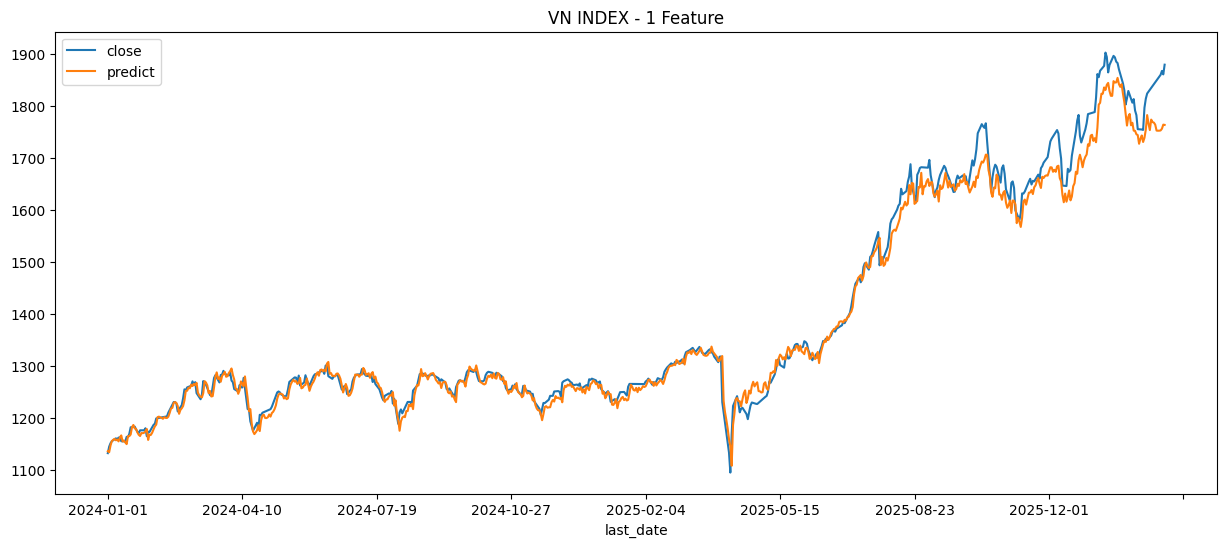

In [239]:
plt.figure(figsize=(15, 6))
plt.title("VN INDEX - 1 Feature")

y_test.plot(ax=plt.gca(), legend="close")
y_predict_plot.plot(ax=plt.gca(), legend="predict", marker=None)

plt.show()

In [240]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

# Convert to numpy arrays (flatten in case they are DataFrames)
y_true = y_test.values.flatten()
y_pred = y_predict_plot.values.flatten()

In [241]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1️⃣ MSE (Mean Squared Error)
mse = mean_squared_error(y_true, y_pred)

# 2️⃣ MAPE (Mean Absolute Percentage Error)
# Avoid division by zero
mape = np.mean(np.where(y_true == 0, 0, np.abs((y_true - y_pred) / y_true))) * 100

# 3️⃣ RMSSE (Root Mean Squared Scaled Error)
# RMSSE needs scaling by naive forecast (lag-1)
denominator = np.mean(np.diff(y_true) ** 2)
rmsse = np.sqrt(mse / denominator)

# 4️⃣ SMAPE (Symmetric MAPE)
denom = np.abs(y_true) + np.abs(y_pred)
smape = np.mean(np.where(denom == 0, 0, 2 * np.abs(y_pred - y_true) / denom)) * 100

# 5️⃣ WAPE (Weighted Absolute Percentage Error)
wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

# 6️⃣ R² (Coefficient of Determination)
r2 = r2_score(y_true, y_pred)

# 7️⃣ Adjusted R²
# Requires number of samples (n) and features (p)
n = len(y_true)
p = X_test_scaled.shape[1]  # make sure X_test exists

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# -----------------------
# Print results
# -----------------------

print(f"MSE: {mse:.4f}")
print(f"MAPE: {mape:.4f} %")
print(f"RMSSE: {rmsse:.4f}")
print(f"SMAPE: {smape:.4f} %")
print(f"WAPE: {wape:.4f}")
print(f"R2: {r2:.4f}")
print(f"Adjusted R2: {adj_r2:.4f}")

MSE: 680.8847
MAPE: 1.1044 %
RMSSE: 2.2816
SMAPE: 1.1133 %
WAPE: 0.0121
R2: 0.9844
Adjusted R2: 0.9682


### Predict

In [242]:
# Get last row and keep 2D shape
last_row = X_test_scaled[-1:]
last_row.shape

(1, 401)

In [243]:
# Convert to tensor
last_row_tensor = torch.tensor(last_row, dtype=torch.float32)

with torch.no_grad():
    y_pred = model(last_row_tensor)

y_pred_inverse = y_scaler.inverse_transform(y_pred.cpu().numpy().reshape(-1, 1))

y_predict = pd.DataFrame(
    y_pred_inverse, index=[X_test_selected.index[-1]], columns=["predict"]
)

y_predict.squeeze()

1763.6941

### Save data

In [244]:
import os
import sys
import pickle
import ipynbname
import json
from torch.utils.tensorboard import SummaryWriter

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from utils.utils import get_current_run_path, save_prediction_figure

result_folder = get_current_run_path()

NB_NAME = ipynbname.name()

# -----------------------
# Save model
# -----------------------
pickle_path = os.path.join(result_folder, "model.pkl")
with open(pickle_path, "wb") as f:
    pickle.dump(model, f)


# -----------------------
# Save metrics to JSON
# -----------------------
result_path = os.path.join(result_folder, "result.json")

results = {
    "MSE": mse,
    "MAPE": mape,
    "RMSSE": rmsse,
    "SMAPE": smape,
    "WAPE": wape,
    "R2": r2,
    "Adjusted_R2": adj_r2,
}

with open(result_path, "w") as f:
    json.dump(results, f, indent=4)

# -----------------------
# Save prediction figure
# -----------------------
fig_path = os.path.join(result_folder, f"{NB_NAME}.jpg")

save_prediction_figure(
    y_test=y_test, y_predict=y_predict_plot, save_path=fig_path, title=f"{NB_NAME}"
)

writer = SummaryWriter(result_folder)

writer.add_scalar("Metrics/MSE", mse, 0)
writer.add_scalar("Metrics/MAPE", mape, 0)
writer.add_scalar("Metrics/RMSSE", rmsse, 0)

writer.close()

print(f"Saved results to: {result_folder}")

Saved results to: lightning_logs\version_12


In [6]:
from win11toast import toast
import ipynbname

NB_NAME = ipynbname.name()

# Simple notification
toast("Completed training", f"Model '{NB_NAME}' trained successfully.")

<Future pending>

(<ToastDismissalReason.USER_CANCELED: 0>,)
